In [ ]:
# This code is part of QCMet.
# 
# (C) Copyright 2024 National Physical Laboratory and National Quantum Computing Centre 
# 
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
# 
#      http://www.apache.org/licenses/LICENSE-2.0
# 
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License


In [1]:
import qiskit
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Relative path to _helpers
import sys
import pathlib
import os
sys.path.insert(0, str(pathlib.Path(os.path.abspath('')).parent.parent.parent.resolve()))
# Disregard any warning on the following imports
from _helpers.circuit_submitter import CircuitSubmitter

### Define T1 circuits

In [2]:
circuits = []
shots = 1024
max_num_identities = 5000
num_identities = np.arange(1, max_num_identities,500)
results = {}
for i in num_identities:
    qc = qiskit.QuantumCircuit(1)
    qc.sx(0)
    qc.sx(0)
    for _ in range(i):
        qc.barrier()
        qc.id(0)
        qc.barrier()
    qc.measure_all()
    circuits.append(qc)

### Run circuits

In [3]:
device_name = "noisy_sim"
submitter = CircuitSubmitter(benchmark_name="t1", device_name=device_name)
submitter.submit_circuits(shots=shots, qasm_strs=[c.qasm() for c in circuits], skip_asking=True, skip_transpilation=True)
counts_list = submitter.retrieve_counts()

NoiseModel:
  Basis gates: ['cx', 'id', 'rz', 'sx']
  Instructions with noise: ['measure', 'sx', 'cx', 'reset', 'id']
  Qubits with noise: [0, 1, 2, 3]
  Specific qubit errors: [('reset', (0,)), ('reset', (1,)), ('reset', (2,)), ('reset', (3,)), ('measure', (0,)), ('measure', (1,)), ('measure', (2,)), ('measure', (3,)), ('sx', (0,)), ('sx', (1,)), ('sx', (2,)), ('sx', (3,)), ('id', (0,)), ('id', (1,)), ('id', (2,)), ('id', (3,)), ('cx', (0, 0)), ('cx', (0, 1)), ('cx', (0, 2)), ('cx', (0, 3)), ('cx', (1, 0)), ('cx', (1, 1)), ('cx', (1, 2)), ('cx', (1, 3)), ('cx', (2, 0)), ('cx', (2, 1)), ('cx', (2, 2)), ('cx', (2, 3)), ('cx', (3, 0)), ('cx', (3, 1)), ('cx', (3, 2)), ('cx', (3, 3))]
Ready to run 10 circuits on noisy_sim with 1024 shots.
Cost: 10 * ($0 + 1024 * $0) = $0.00.
Circuits have been submitted
2024-07-05 16:41:12 All circuits are finished


In [6]:
probs = [res['1']/shots for res in counts_list]

In [7]:
def exp_func(x, amp, dr):
    return amp * np.exp(x * -1 / dr)

In [8]:
popt, pcov = curve_fit(exp_func, num_identities, probs, p0=[1, 1000], method='trf')
x_to_fit = np.linspace(0,5000,5000)
fitted_probs = exp_func(x_to_fit, *popt)

T1 = 1035.293779962006 in terms of the number of 1 qubit gates


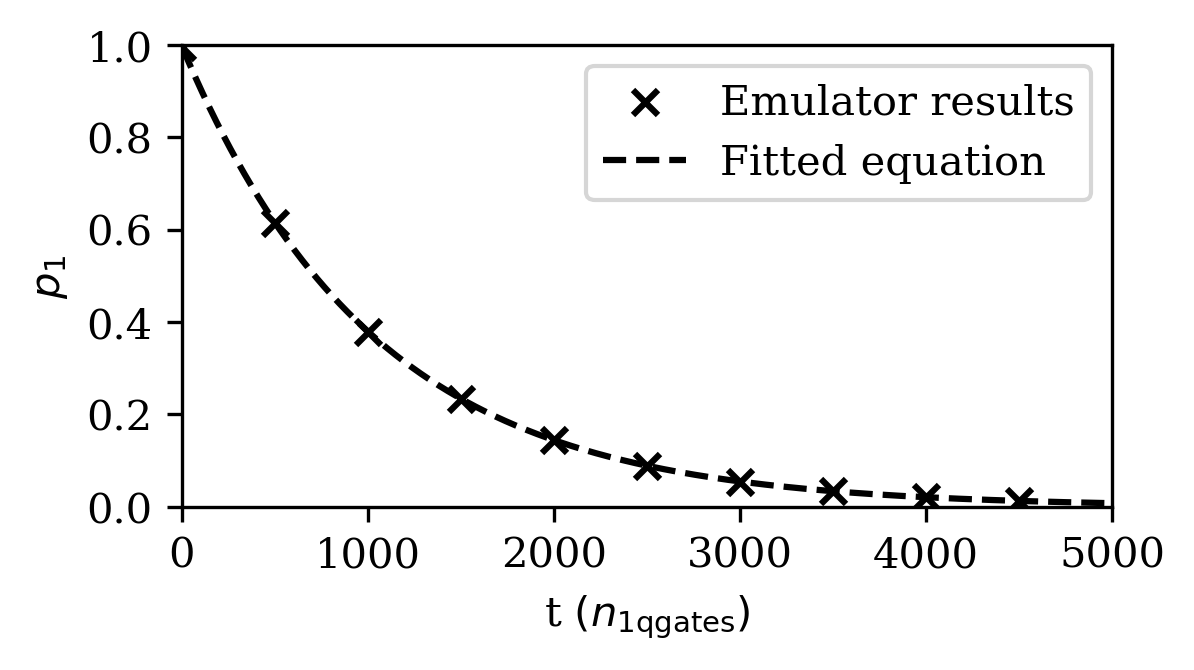

In [12]:
print(f'T1 = {popt[1]} in terms of the number of 1 qubit gates')
fig = plt.figure(figsize=(4,2), dpi=300)
plt.rc('font', family='serif')
plt.xlim((0,x_to_fit[-1])) 
plt.ylim((0,1))
plt.xlabel(r't $(n_{\mathrm{1q gates}})$')
plt.ylabel(r'$p_1$')
plt.scatter(num_identities, probs, color='black', marker='x', label='Emulator results')
plt.plot(x_to_fit, fitted_probs, color='black', ls='--', label='Fitted equation')
plt.legend()
plt.show()
